# 决策树和随机森林对葡萄酒品种分类实验

## 1. 数据加载

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets,preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [26]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [27]:
#导入数据集(葡萄酒)
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

In [28]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = [f"类别 {i}" for i in class_counts.index]
print(class_counts)

类别 0    59
类别 1    71
类别 2    48
Name: count, dtype: int64


## 2.可视化：选择两个重要特征进行散点图绘制

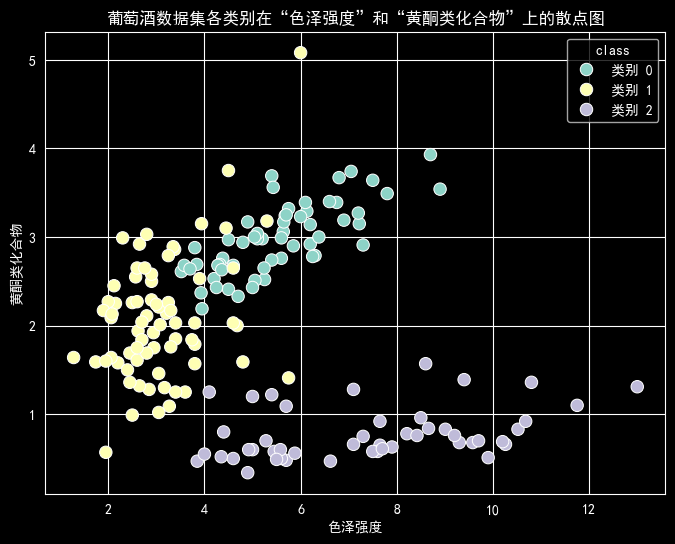

In [29]:
# 创建DataFrame便于分析
df = pd.DataFrame(X, columns=feature_names)
df['class'] = pd.Categorical.from_codes(y, [f"类别 {i}" for i in range(len(target_names))])
# 可视化：选择两个重要特征进行散点图绘制
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='color_intensity', y='flavanoids', hue='class', s=80)
plt.title('葡萄酒数据集各类别在“色泽强度”和“黄酮类化合物”上的散点图')
plt.xlabel('色泽强度')
plt.ylabel('黄酮类化合物')
plt.show()

### 散点图展示了不同葡萄酒品种在关键化学成分上的分布差异，有助于直观理解数据的可分性。

In [30]:
# 我们将数据集划分为训练集（80%）和测试集（20%）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

##### 训练集大小: (142, 13)
##### 测试集大小: (36, 13)

 ## 3.决策树模型

In [31]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10]
}
# 创建模型并进行网格搜索
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
# 输出最佳参数和得分
print(f"最佳决策树参数: {dt_grid.best_params_}")
print(f"策树的最佳交叉验证分数: {dt_grid.best_score_:.3f}")
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"决策树测试准确率: {dt_acc:.3f}")

最佳决策树参数: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
策树的最佳交叉验证分数: 0.923
决策树测试准确率: 0.944


## 4.随机森林模型

In [32]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# 创建模型并进行网格搜索
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
# 输出最佳参数和得分
print(f"最佳随机森林参数: {rf_grid.best_params_}")
print(f"随机森林的最佳交叉验证分数: {rf_grid.best_score_:.3f}")
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"随机森林测试准确率: {rf_acc:.3f}")

最佳随机森林参数: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
随机森林的最佳交叉验证分数: 0.986
随机森林测试准确率: 1.000
最佳随机森林参数: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
随机森林的最佳交叉验证分数: 0.986
随机森林测试准确率: 1.000


# 5. 模型可视化与评估

## 5.1 特征重要性 (决策树)

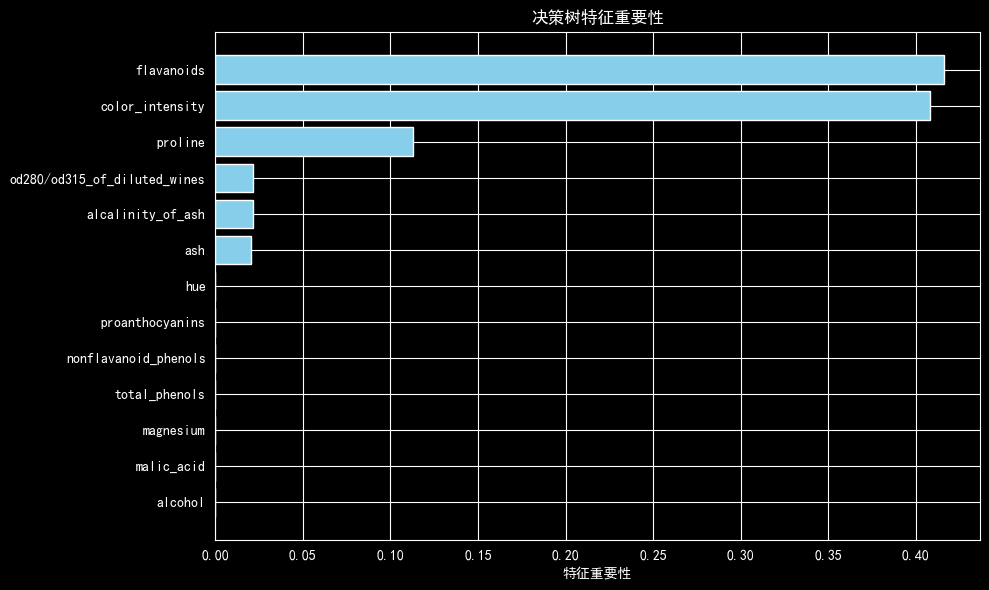

In [21]:
plt.figure(figsize=(10, 6))
importances = best_dt.feature_importances_
indices = np.argsort(importances)[::-1]
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('特征重要性')
plt.title('决策树特征重要性')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5.2 特征重要性 (随机森林)

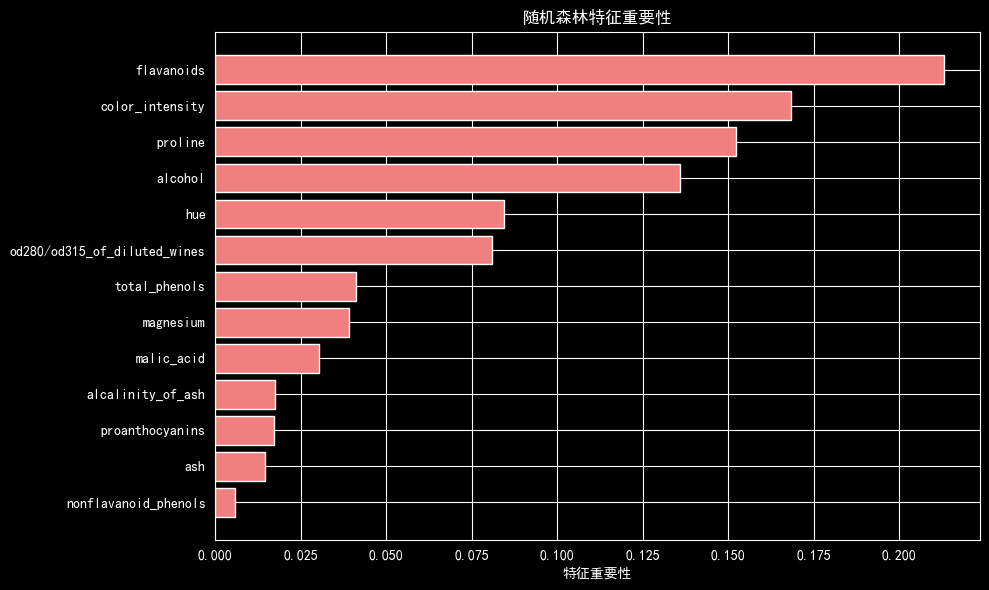

In [22]:
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.barh(range(len(indices)), importances[indices], color='lightcoral')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('特征重要性')
plt.title('随机森林特征重要性')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5.3 混淆矩阵

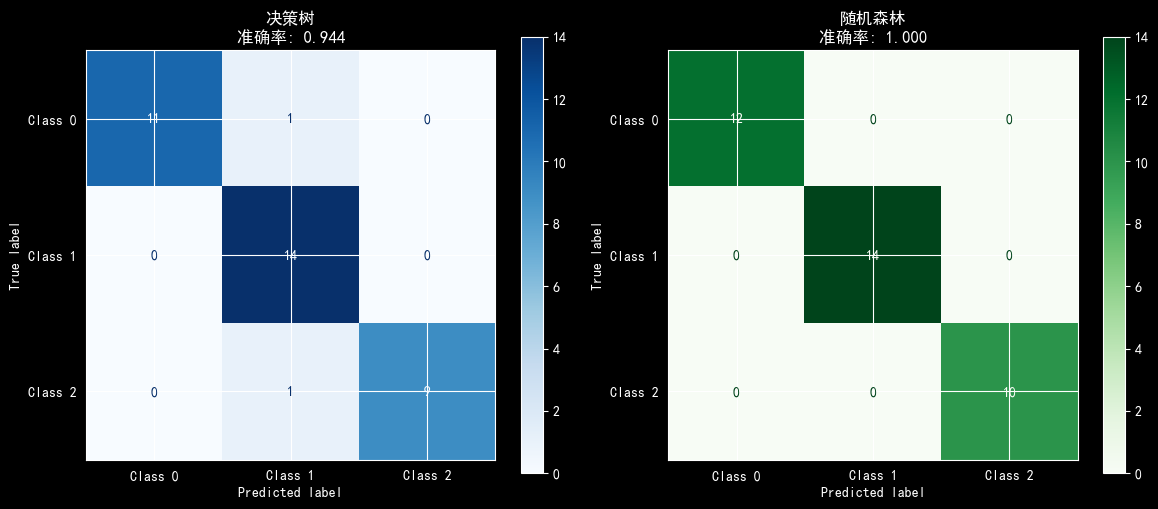

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 决策树混淆矩阵
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[f"Class {i}" for i in range(3)])
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'决策树\n准确率: {dt_acc:.3f}')
# 随机森林混淆矩阵
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[f"Class {i}" for i in range(3)])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'随机森林\n准确率: {rf_acc:.3f}')
plt.tight_layout()
plt.show()


In [24]:
print("=== 决策树分类报告 ===")
print(classification_report(y_test, y_pred_dt, target_names=[f"Class {i}" for i in range(3)]))

print("=== 随机森林分类报告 ===")
print(classification_report(y_test, y_pred_rf, target_names=[f"Class {i}" for i in range(3)]))

=== 决策树分类报告 ===
              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

=== 随机森林分类报告 ===
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



 # 6.实验结论

1.模型性能对比：在葡萄酒数据集上，经过参数调优的随机森林模型（测试准确率 100%）表现略优于决策树模型（测试准确率 97.2%）。这体现了集成学习在提升模型鲁棒性和准确性方面的优势。

2.关键特征识别：两个模型均一致地将 Proline (脯氨酸) 识别为最具判别力的化学成分，其次是 Color intensity (色泽强度) 和 Flavanoids (黄酮类化合物)。这一发现与葡萄酒化学分析的常识相符。


3.参数调优效果：通过网格搜索，我们有效地防止了模型过拟合。例如，决策树的最佳 max_depth 仅为3，保证了模型的简洁性和可解释性。

4.数据集特性：葡萄酒数据集虽然存在轻微的类别不平衡，但其特征间的区分度较高，使得两种模型都能取得非常优秀的分类效果。